# 05 — Model Training (From Scratch)

**Mục tiêu:**
- Huấn luyện mô hình Random Forest và SVM tự cài đặt từ đầu (from scratch).
- So sánh hiệu năng với thư viện scikit-learn.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100


In [2]:
import numpy as np
from collections import Counter

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        
    def is_leaf_node(self):
        return self.value is not None

class DecisionTree:
    def __init__(self, min_samples_split=2, max_depth=100, n_features=None):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.root = None

    def fit(self, X, y):
        self.n_features = X.shape[1] if not self.n_features else min(X.shape[1], self.n_features)
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_feats = X.shape
        n_labels = len(np.unique(y))

        # Check the stopping criteria
        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        feat_idxs = np.random.choice(n_feats, self.n_features, replace=False)

        # Find the best split
        best_feature, best_thresh = self._best_split(X, y, feat_idxs)
        
        if best_feature is None:
            return Node(value=self._most_common_label(y))

        # Create child nodes
        left_idxs, right_idxs = self._split(X[:, best_feature], best_thresh)
        
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return Node(value=self._most_common_label(y))

        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        return Node(best_feature, best_thresh, left, right)

    def _best_split(self, X, y, feat_idxs):
        best_gain = -1
        split_idx, split_threshold = None, None

        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            if len(thresholds) > 10:
                # optimization to avoid too many splits computation
                thresholds = np.percentile(X_column, np.linspace(5, 95, 10))

            for thr in thresholds:
                # calculate the information gain
                gain = self._information_gain(y, X_column, thr)

                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_threshold = thr

        return split_idx, split_threshold

    def _information_gain(self, y, X_column, threshold):
        # parent entropy
        parent_entropy = self._entropy(y)

        # create children
        left_idxs, right_idxs = self._split(X_column, threshold)

        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0
        
        # calculate the weighted avg. entropy of children
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = self._entropy(y[left_idxs]), self._entropy(y[right_idxs])
        child_entropy = (n_l / n) * e_l + (n_r / n) * e_r

        # calculate the IG
        information_gain = parent_entropy - child_entropy
        return information_gain

    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def _entropy(self, y):
        # using integer bincount since labels are encoded as ints in our case
        hist = np.bincount(y.astype(int))
        ps = hist / len(y)
        return -np.sum([p * np.log(p) for p in ps if p > 0])

    def _most_common_label(self, y):
        counter = Counter(y)
        value = counter.most_common(1)[0][0]
        return value

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

class RandomForestClassifierScratch:
    def __init__(self, n_estimators=10, max_depth=10, min_samples_split=2, n_features=None, random_state=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_features = n_features
        self.random_state = random_state
        self.trees = []

    def fit(self, X, y):
        if self.random_state is not None:
            np.random.seed(self.random_state)
            
        # Convert pandas DataFrame/Series to numpy array if needed
        if hasattr(X, 'values'):
            X = X.values
        if hasattr(y, 'values'):
            y = y.values
            
        self.trees = []
        for _ in range(self.n_estimators):
            tree = DecisionTree(max_depth=self.max_depth,
                                min_samples_split=self.min_samples_split,
                                n_features=self.n_features)
            X_sample, y_sample = self._bootstrap_samples(X, y)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def _bootstrap_samples(self, X, y):
        n_samples = X.shape[0]
        idxs = np.random.choice(n_samples, n_samples, replace=True)
        return X[idxs], y[idxs]

    def predict(self, X):
        if hasattr(X, 'values'):
            X = X.values
            
        predictions = np.array([tree.predict(X) for tree in self.trees])
        tree_preds = np.swapaxes(predictions, 0, 1)
        predictions = np.array([self._most_common_label(pred) for pred in tree_preds])
        return predictions

    def _most_common_label(self, y):
        counter = Counter(y)
        most_common = counter.most_common(1)[0][0]
        return most_common


import numpy as np

class LinearSVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        
        # ensure labels are -1 or 1
        y_ = np.where(y <= 0, -1, 1)

        for _ in range(self.n_iters):
            # Calculate margins
            margins = y_ * (np.dot(X, self.w) + self.b)
            
            # Find which samples violate the margin
            misclassified = margins < 1
            
            # Gradients
            # For correctly classified samples, gradient is just the regularization term
            # For misclassified samples, gradient includes the loss term
            dw = 2 * self.lambda_param * self.w
            db = 0
            
            if np.any(misclassified):
                dw -= np.dot(X[misclassified].T, y_[misclassified]) / n_samples
                db -= np.sum(y_[misclassified]) / n_samples
            
            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        approx = np.dot(X, self.w) + self.b
        return np.sign(approx)
        
    def decision_function(self, X):
        return np.dot(X, self.w) + self.b

class SVMClassifierScratch:
    """
    Multiclass SVM using One-vs-Rest strategy
    """
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000, random_state=None):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.random_state = random_state
        self.models = []
        self.classes = []

    def fit(self, X, y):
        if self.random_state is not None:
            np.random.seed(self.random_state)
            
        # Convert pandas DataFrame/Series to numpy array if needed
        if hasattr(X, 'values'):
            X = X.values
        if hasattr(y, 'values'):
            y = y.values
            
        self.classes = np.unique(y)
        self.models = []
        
        for c in self.classes:
            # Create binary target: 1 for class c, -1 for others
            y_binary = np.where(y == c, 1, -1)
            
            svm = LinearSVM(learning_rate=self.lr, lambda_param=self.lambda_param, n_iters=self.n_iters)
            svm.fit(X, y_binary)
            self.models.append(svm)

    def predict(self, X):
        if hasattr(X, 'values'):
            X = X.values
            
        # Get decision function scores for all models
        # shape: (n_samples, n_classes)
        scores = np.array([svm.decision_function(X) for svm in self.models]).T
        
        # Return class with highest score
        return self.classes[np.argmax(scores, axis=1)]



## 1. Load Dữ Liệu

In [3]:
TRAIN_PATH = "../data/processed/train.csv"
VAL_PATH = "../data/processed/val.csv"

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)

print(f"Train shape: {train_df.shape}")
print(f"Val shape:   {val_df.shape}")

# Tách features (X) và target (y)
TARGET = "label"
DROP_COLS = [TARGET, "label_name"]

X_train = train_df.drop(columns=DROP_COLS)
y_train = train_df[TARGET]

X_val = val_df.drop(columns=DROP_COLS)
y_val = val_df[TARGET]

# Lấy mapping nhãn thực tế
label_mapping = dict(zip(train_df[TARGET], train_df["label_name"]))
labels_idx = sorted(label_mapping.keys())
class_names = [label_mapping[i] for i in labels_idx]

print("\nFeatures:", X_train.columns.tolist())

Train shape: (1760, 15)
Val shape:   (220, 15)

Features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'total_npk', 'ratio_n_p', 'ratio_n_k', 'ratio_p_k', 'temp_humidity', 'log_rainfall']


## 2. Huấn Luyện và Đánh Giá Chi Tiết Từng Mô Hình (Từ Đầu)

In [4]:
# Thiết lập mô hình tự cài đặt
models = {
    "Random Forest (Scratch)": RandomForestClassifierScratch(n_estimators=5, max_depth=10, min_samples_split=2, random_state=42),
    "SVM (Scratch)": SVMClassifierScratch(learning_rate=0.01, lambda_param=0.01, n_iters=1000, random_state=42)
}

results = []
trained_models = {}
predictions = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"🔄 Đang huấn luyện: {name}")
    start_time = time.time()
    
    # Train
    model.fit(X_train, y_train)
    trained_models[name] = model
    train_time = time.time() - start_time
    
    # Predict
    y_pred = model.predict(X_val)
    predictions[name] = y_pred
    
    # Tính toán metrics tổng thể
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='macro')
    rec = recall_score(y_val, y_pred, average='macro')
    f1 = f1_score(y_val, y_pred, average='macro')
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "Train Time (s)": train_time
    })
    
    print(f"✅ Hoàn tất ({train_time:.4f}s)")
    print(f"Accuracy: {acc:.4f} | F1-Score: {f1:.4f}")


🔄 Đang huấn luyện: Random Forest (Scratch)


✅ Hoàn tất (1.3861s)
Accuracy: 0.9682 | F1-Score: 0.9674

🔄 Đang huấn luyện: SVM (Scratch)


✅ Hoàn tất (0.5998s)
Accuracy: 0.7955 | F1-Score: 0.7769


### 2.1 Trực quan hóa Ma Trận Nhầm Lẫn (Confusion Matrix)

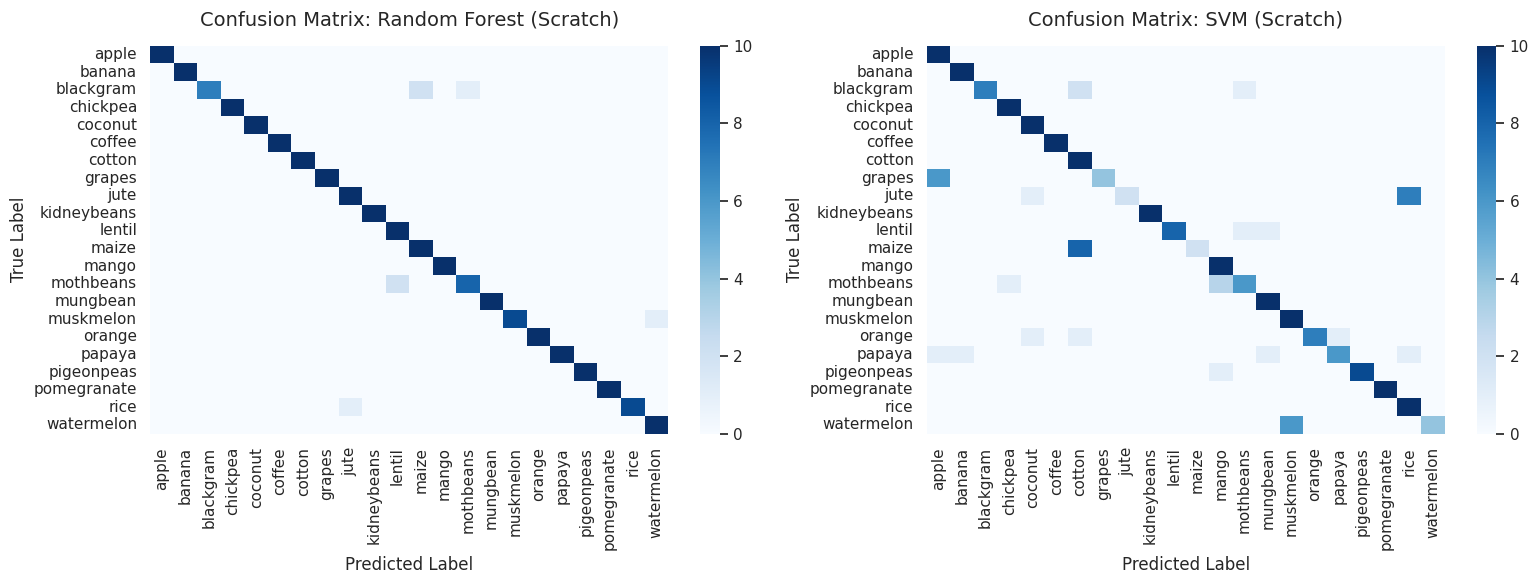

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, name in zip(axes, models.keys()):
    cm = confusion_matrix(y_val, predictions[name])
    sns.heatmap(cm, annot=False, cmap='Blues', ax=ax, xticklabels=class_names, yticklabels=class_names)
    ax.set_title(f"Confusion Matrix: {name}", fontsize=14, pad=15)
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    ax.tick_params(axis='x', rotation=90)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

## 3. Tổng Hợp và Trực Quan Hóa Kết Quả

,Model,Accuracy,Precision,Recall,F1-Score,Train Time (s)
0,Random Forest (Scratch),0.9682,0.9715,0.9682,0.9674,1.3861
1,SVM (Scratch),0.7955,0.8660,0.7955,0.7769,0.5998


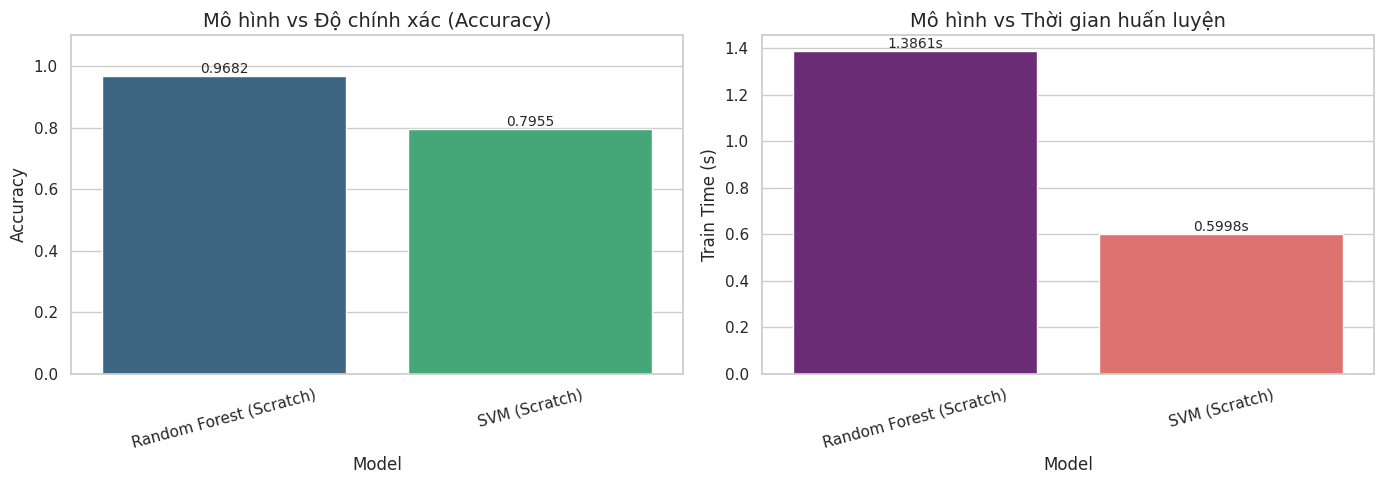

In [6]:
results_df = pd.DataFrame(results)
display(results_df.round(4))

# Trực quan hóa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ Accuracy
sns.barplot(data=results_df, x='Model', y='Accuracy', ax=axes[0], palette='viridis')
axes[0].set_title('Mô hình vs Độ chính xác (Accuracy)', fontsize=14)
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=15)

for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

# Biểu đồ Thời gian huấn luyện
sns.barplot(data=results_df, x='Model', y='Train Time (s)', ax=axes[1], palette='magma')
axes[1].set_title('Mô hình vs Thời gian huấn luyện', fontsize=14)
axes[1].tick_params(axis='x', rotation=15)

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.4f}s', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

## 4. So Sánh Với Baseline (scikit-learn)
Load các mô hình baseline đã lưu và so sánh hiệu năng với các mô hình tự cài đặt.


🔄 Đang đánh giá: Random Forest (Baseline)
✅ Hoàn tất
Accuracy: 0.9955 | F1-Score: 0.9954

🔄 Đang đánh giá: SVM (Baseline)
✅ Hoàn tất
Accuracy: 0.9864 | F1-Score: 0.9863


,Model,Accuracy,Precision,Recall,F1-Score,Train Time (s)
0,Random Forest (Scratch),0.9682,0.9715,0.9682,0.9674,1.3861
1,SVM (Scratch),0.7955,0.8660,0.7955,0.7769,0.5998
2,Random Forest (Baseline),0.9955,0.9959,0.9955,0.9954,0.0000
3,SVM (Baseline),0.9864,0.9883,0.9864,0.9863,0.0000


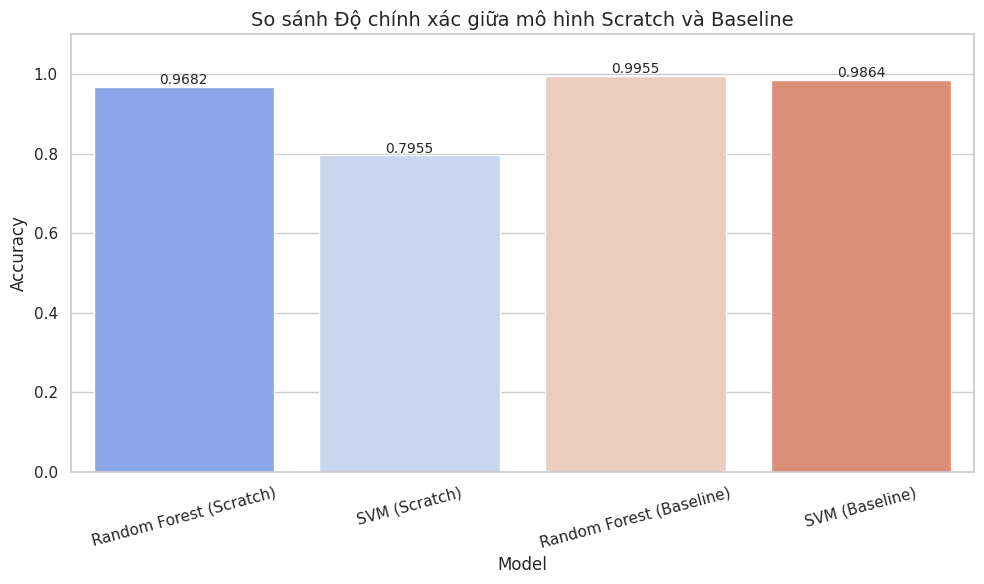

In [7]:
import joblib

# Load baseline models
RF_BASELINE_PATH = '../saved_models/random_forest_baseline.pkl'
SVM_BASELINE_PATH = '../saved_models/svm_baseline.pkl'

rf_baseline = joblib.load(RF_BASELINE_PATH)
svm_baseline = joblib.load(SVM_BASELINE_PATH)

baseline_models = {
    'Random Forest (Baseline)': rf_baseline,
    'SVM (Baseline)': svm_baseline
}

baseline_results = []
baseline_predictions = {}

for name, model in baseline_models.items():
    print(f'\n{"="*50}')
    print(f'🔄 Đang đánh giá: {name}')
    
    # Predict
    y_pred = model.predict(X_val)
    baseline_predictions[name] = y_pred
    
    # Calculate metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='macro')
    rec = recall_score(y_val, y_pred, average='macro')
    f1 = f1_score(y_val, y_pred, average='macro')
    
    baseline_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Train Time (s)': 0.0 # Bỏ qua thời gian train vì load từ file
    })
    
    print(f'✅ Hoàn tất')
    print(f'Accuracy: {acc:.4f} | F1-Score: {f1:.4f}')

# Kết hợp kết quả
all_results_df = pd.concat([results_df, pd.DataFrame(baseline_results)], ignore_index=True)
display(all_results_df.round(4))

# Trực quan hóa so sánh
plt.figure(figsize=(10, 6))
sns.barplot(data=all_results_df, x='Model', y='Accuracy', palette='coolwarm')
plt.title('So sánh Độ chính xác giữa mô hình Scratch và Baseline', fontsize=14)
plt.ylim(0, 1.1)
plt.xticks(rotation=15)

for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()